# Procesamiento de Lenguaje Natural
## Desafío 3: Modelo de lenguaje con tokenización por caracteres

### Ariel Cabello

Corpus: El arte de la guerra (Sun Tzu, traducción al español — textos.info)

### Consigna
1. Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
2. Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
3. Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
4. Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de **greedy search** y **beam search** determinístico y estocástico. Observar el efecto de la **temperatura** en la generación de secuencias.

### Decisiones de diseño
- **Tokenización por carácter**
- **Estructura many-to-many**: el target es la secuencia desplazada 1 posición, para que el gradiente se propague en cada paso temporal
- **Tres arquitecturas comparadas**: `SimpleRNN`, `LSTM` y `GRU` con la misma estructura base, para aislar el efecto de la celda recurrente
- **Early stopping por perplejidad en validación** guardando el mejor modelo

## 1. Imports y configuración

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import bs4 as bs

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense,
    TimeDistributed, CategoryEncoding
)
from tensorflow.keras.models import Sequential
from scipy.special import softmax

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU disponible: []


## 2. Carga del corpus

Se descargó *El arte de la guerra* de Sun Tzu desde [textos.info](https://www.textos.info/sun-tzu/el-arte-de-la-guerra/ebook). Es un texto corto (~86k caracteres) con estilo sentencioso y muchas repeticiones estructurales ("el general que...", "los cinco factores...", "en la guerra..."), lo cual es útil para un modelo a nivel de caracteres porque le da patrones recurrentes para aprender.

Normalizo los saltos de línea (`\r\n` del HTML) colapsándolos en espacios simples, para que el vocabulario quede limpio.

In [5]:
import re

url = "https://www.textos.info/sun-tzu/el-arte-de-la-guerra/ebook"
raw_html = urllib.request.urlopen(url).read()

parser = "html.parser"
if bs.builder_registry.lookup("lxml") is not None:
    parser = "lxml"

article_html = bs.BeautifulSoup(raw_html, parser)
paragraphs = article_html.find_all("p")

corpus = " ".join(p.text for p in paragraphs).lower()
# Colapsar cualquier whitespace (incluyendo \r\n) a un único espacio
corpus = re.sub(r"\s+", " ", corpus).strip()

print(f"Parser HTML usado: {parser}")
print(f"Longitud del corpus: {len(corpus):,} caracteres")
print(f"\nPrimeros 500 caracteres:\n{corpus[:500]}")

Parser HTML usado: html.parser
Longitud del corpus: 85,021 caracteres

Primeros 500 caracteres:
sun tzu dice: la guerra es de vital importancia para el estado; es el dominio de la vida o de la muerte, el camino hacia la supervivencia o la pérdida del imperio: es forzoso manejarla bien. no reflexionar seriamente sobre todo lo que le concierne es dar prueba de una culpable indiferencia en lo que respecta a la conservación o pérdida de lo que nos es mas querido; y ello no debe ocurrir entre nosotros. hay que valorarla en términos de cinco factores fundamentales, y hacer comparaciones entre di


## 3. Tokenización por caracteres

El vocabulario es el conjunto de caracteres únicos del corpus. Ordeno alfabéticamente para que los índices sean reproducibles entre corridas.

In [6]:
chars_vocab = sorted(set(corpus))
vocab_size = len(chars_vocab)
print(f"Tamaño del vocabulario: {vocab_size} caracteres únicos")
print(f"Caracteres: {repr(''.join(chars_vocab))}")

Tamaño del vocabulario: 54 caracteres únicos
Caracteres: ' "(),-./012346789:;?abcdefghijklmnopqrstuvxyz¿áéíñóúü—'


In [7]:
char2idx = {ch: idx for idx, ch in enumerate(chars_vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

tokenized_text = [char2idx[ch] for ch in corpus]
print(f"Primeros 80 tokens: {tokenized_text[:80]}")
print(f"Texto original:     {corpus[:80]}")

Primeros 80 tokens: [38, 40, 33, 0, 39, 44, 40, 0, 23, 28, 22, 24, 17, 0, 31, 20, 0, 26, 40, 24, 37, 37, 20, 0, 24, 38, 0, 23, 24, 0, 41, 28, 39, 20, 31, 0, 28, 32, 35, 34, 37, 39, 20, 33, 22, 28, 20, 0, 35, 20, 37, 20, 0, 24, 31, 0, 24, 38, 39, 20, 23, 34, 18, 0, 24, 38, 0, 24, 31, 0, 23, 34, 32, 28, 33, 28, 34, 0, 23, 24]
Texto original:     sun tzu dice: la guerra es de vital importancia para el estado; es el dominio de


## 4. Estructuración del dataset

Uso ventana de contexto de **100 caracteres** y estructura **many-to-many**: el target `y` es la entrada `X` desplazada 1 posición, de modo que cada paso temporal aporta señal de gradiente (mejor que many-to-one, donde solo el último paso propaga).

Para training genero secuencias con ventana deslizante de paso 1 (data augmentation). Para validación reservo el último 10% del texto y lo parto en secuencias sin solapamiento, para medir perplejidad sobre texto no visto.

In [8]:
max_context_size = 100
BATCH_SIZE = 256
p_val = 0.1

num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

train_text = tokenized_text[:-num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size:]

# Validación: secuencias sin solapamiento
tokenized_sentences_val = [
    val_text[i * max_context_size:(i + 1) * max_context_size]
    for i in range(num_val)
]

# Train: ventana deslizante de paso 1
tokenized_sentences_train = [
    train_text[i:i + max_context_size]
    for i in range(len(train_text) - max_context_size + 1)
]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X, y))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Secuencias de entrenamiento: {X.shape}")
print(f"Secuencias de validación: {len(tokenized_sentences_val)}")
print(f"Vocabulario: {vocab_size}")
print(f"\nX[0][:15]: {X[0, :15]}")
print(f"y[0][:15]: {y[0, :15]}  (desplazado 1)")

Secuencias de entrenamiento: (76321, 100)
Secuencias de validación: 86
Vocabulario: 54

X[0][:15]: [38 40 33  0 39 44 40  0 23 28 22 24 17  0 31]
y[0][:15]: [40 33  0 39 44 40  0 23 28 22 24 17  0 31 20]  (desplazado 1)


## 5. Callback de perplejidad

La perplejidad mide qué tan "sorprendido" está el modelo por el siguiente token. Perplejidad = 1 es predicción perfecta, perplejidad = `vocab_size` equivale a elegir uniformemente al azar.

El callback:
- Al final de cada época calcula la perplejidad media sobre validación generando todas las sub-secuencias de cada secuencia de validación.
- Guarda el mejor modelo (menor perplejidad).
- Aplica **early stopping** si no mejora durante `patience=5` épocas.

In [9]:
class PplCallback(keras.callbacks.Callback):
    """Perplejidad en validación + early stopping + guardado del mejor modelo."""

    def __init__(self, val_data, history_ppl, model_name="model", patience=5, max_val_seqs=40):
        super().__init__()
        self.val_data = val_data[:max_val_seqs]
        self.history_ppl = history_ppl
        self.model_name = model_name
        self.patience = patience
        self.min_score = np.inf
        self.patience_counter = 0

        # Pre-armar sub-secuencias y targets para cada secuencia de validación
        self.val_groups = []
        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            targets = [seq[i] for i in range(1, len_seq)]
            if subseq:
                padded = pad_sequences(subseq, maxlen=max_context_size, padding="pre")
                self.val_groups.append((padded, targets))

    def on_epoch_end(self, epoch, logs=None):
        scores = []
        for padded, targets in self.val_groups:
            preds = self.model.predict(padded, verbose=0, batch_size=64)
            probs = np.array([preds[i, -1, targets[i]] for i in range(len(targets))])
            ppl = np.exp(-np.sum(np.log(probs + 1e-10)) / len(probs))
            scores.append(ppl)

        current = float(np.mean(scores))
        self.history_ppl.append(current)
        print(f"\n  Perplejidad media (val): {current:.3f}")

        if current < self.min_score:
            self.min_score = current
            self.model.save(f"{self.model_name}.keras")
            print(f"  Mejor modelo guardado -> {self.model_name}.keras")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("  Early stopping")
                self.model.stop_training = True

## 6. Definición de arquitecturas

Comparo tres celdas recurrentes manteniendo **idéntica estructura base** (entrada OHE via `CategoryEncoding` + `TimeDistributed`, una capa recurrente de 256 unidades con `return_sequences=True` y dropout 0.2, y `Dense` softmax de salida). Así, la única variable controlada es el tipo de celda.

- **`SimpleRNN`** (celda de Elman): la más básica; baseline. Sufre *vanishing gradient* con secuencias largas.
- **`LSTM`**: compuertas forget/input/output + estado de celda separado. ~4× los parámetros de SimpleRNN.
- **`GRU`**: simplificación de LSTM (2 compuertas en vez de 3). Suele igualar a LSTM con menos parámetros.

Optimizador `rmsprop` (recomendado para RNNs) y `sparse_categorical_crossentropy`.

In [10]:
def construir_modelo(tipo_celda, unidades=256, dropout=0.2):
    """Construye modelo con la celda recurrente indicada."""
    celdas = {"SimpleRNN": SimpleRNN, "LSTM": LSTM, "GRU": GRU}

    modelo = Sequential([
        TimeDistributed(
            CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
            input_shape=(None, 1)
        ),
        celdas[tipo_celda](unidades, return_sequences=True, dropout=dropout),
        Dense(vocab_size, activation="softmax")
    ], name=f"modelo_{tipo_celda.lower()}")

    modelo.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop")
    return modelo

### 6.1 SimpleRNN (baseline)

In [11]:
modelo_rnn = construir_modelo("SimpleRNN")
modelo_rnn.summary()

d:\ariel_D\UBA\NLP\desafios\.venv\Lib\site-packages\keras\src\layers\core\wrapper.py:25: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "modelo_simplernn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 54)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 256)      │        79,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 54)       │        13,878 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,494 (365.21 KB)

 Trainable params: 93,494 (365.21 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
historia_ppl_rnn = []
hist_rnn = modelo_rnn.fit(
    train_dataset,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, historia_ppl_rnn, model_name="modelo_rnn")],
    verbose=1
)

Epoch 1/30
298/299 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 2.7706
  Perplejidad media (val): 10.086
  Mejor modelo guardado -> modelo_rnn.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - loss: 2.5253
Epoch 2/30
298/299 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 2.2660
  Perplejidad media (val): 9.020
  Mejor modelo guardado -> modelo_rnn.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 34s 115ms/step - loss: 2.2198
Epoch 3/30
298/299 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 2.1786
  Perplejidad media (val): 8.581
  Mejor modelo guardado -> modelo_rnn.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 36s 119ms/step - loss: 2.1449
Epoch 4/30
298/299 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 2.1301
  Perplejidad media (val): 8.263
  Mejor modelo guardado -> modelo_rnn.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 39s 130ms/step - loss: 2.0960
Epoch 5/30
298/299 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 2.0879
  Perplejidad media (val): 7.997
  Mejor modelo guardado -> modelo_rnn.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 36s 

### 6.2 LSTM

In [13]:
modelo_lstm = construir_modelo("LSTM")
modelo_lstm.summary()

Model: "modelo_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 54)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 256)      │       318,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 54)       │        13,878 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,342 (1.27 MB)

 Trainable params: 332,342 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
historia_ppl_lstm = []
hist_lstm = modelo_lstm.fit(
    train_dataset,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, historia_ppl_lstm, model_name="modelo_lstm")],
    verbose=1
)

Epoch 1/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 2.9678
  Perplejidad media (val): 12.928
  Mejor modelo guardado -> modelo_lstm.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 117s 378ms/step - loss: 2.7894
Epoch 2/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 2.4965
  Perplejidad media (val): 10.413
  Mejor modelo guardado -> modelo_lstm.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 111s 372ms/step - loss: 2.4313
Epoch 3/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 2.3419
  Perplejidad media (val): 9.395
  Mejor modelo guardado -> modelo_lstm.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 111s 372ms/step - loss: 2.3053
Epoch 4/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - loss: 2.2679
  Perplejidad media (val): 8.909
  Mejor modelo guardado -> modelo_lstm.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 113s 379ms/step - loss: 2.2386
Epoch 5/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 2.2154
  Perplejidad media (val): 8.452
  Mejor modelo guardado -> modelo_lstm.keras
299/299 ━━━━━━━━━━━━━━━

### 6.3 GRU

In [15]:
modelo_gru = construir_modelo("GRU")
modelo_gru.summary()

Model: "modelo_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 54)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       239,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 54)       │        13,878 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,494 (990.21 KB)

 Trainable params: 253,494 (990.21 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
historia_ppl_gru = []
hist_gru = modelo_gru.fit(
    train_dataset,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, historia_ppl_gru, model_name="modelo_gru")],
    verbose=1
)

Epoch 1/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 2.8738
  Perplejidad media (val): 9.932
  Mejor modelo guardado -> modelo_gru.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 98s 311ms/step - loss: 2.5963
Epoch 2/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 2.3086
  Perplejidad media (val): 8.686
  Mejor modelo guardado -> modelo_gru.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 84s 281ms/step - loss: 2.2627
Epoch 3/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 2.2005
  Perplejidad media (val): 8.089
  Mejor modelo guardado -> modelo_gru.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 90s 303ms/step - loss: 2.1615
Epoch 4/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - loss: 2.1171
  Perplejidad media (val): 7.546
  Mejor modelo guardado -> modelo_gru.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 94s 313ms/step - loss: 2.0788
Epoch 5/30
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - loss: 2.0469
  Perplejidad media (val): 7.143
  Mejor modelo guardado -> modelo_gru.keras
299/299 ━━━━━━━━━━━━━━━━━━━━ 90s 3

## 7. Comparación de arquitecturas

Grafico la perplejidad en validación para las tres arquitecturas. Menor es mejor.

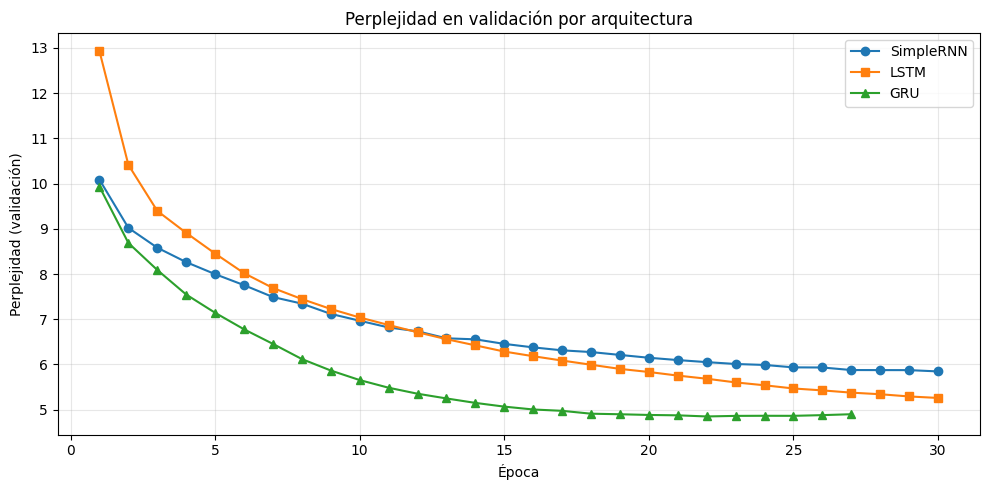

RESUMEN DE PERPLEJIDAD MÍNIMA EN VALIDACIÓN
  SimpleRNN :   5.847 (época 30)
  LSTM      :   5.260 (época 30)
  GRU       :   4.851 (época 22)

Mejor modelo: GRU


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

for nombre, h, marker in [
    ("SimpleRNN", historia_ppl_rnn, "o"),
    ("LSTM", historia_ppl_lstm, "s"),
    ("GRU", historia_ppl_gru, "^"),
]:
    if h:
        ax.plot(range(1, len(h) + 1), h, marker=marker, label=nombre)

ax.set_xlabel("Época")
ax.set_ylabel("Perplejidad (validación)")
ax.set_title("Perplejidad en validación por arquitectura")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 45)
print("RESUMEN DE PERPLEJIDAD MÍNIMA EN VALIDACIÓN")
print("=" * 45)
resultados = {}
for nombre, h in [("SimpleRNN", historia_ppl_rnn), ("LSTM", historia_ppl_lstm), ("GRU", historia_ppl_gru)]:
    if h:
        mejor = min(h)
        epoca = h.index(mejor) + 1
        resultados[nombre] = mejor
        print(f"  {nombre:10s}: {mejor:7.3f} (época {epoca})")
print("=" * 45)

mejor_modelo_nombre = min(resultados, key=resultados.get)
print(f"\nMejor modelo: {mejor_modelo_nombre}")

### Interpretación

La jerarquía observada es **GRU (4.85) < LSTM (5.26) < SimpleRNN (5.85)** en perplejidad (menor es mejor), consistente con lo esperable teóricamente: las compuertas de LSTM/GRU mitigan el *vanishing gradient* y capturan dependencias más largas que la celda de Elman a lo largo de los 100 caracteres de contexto. GRU logra el mejor resultado con ~253k parámetros vs ~332k de LSTM, confirmando su eficiencia.

**Observación importante sobre la convergencia:** ni `SimpleRNN` ni `LSTM` activaron el early stopping, su mejor perplejidad se dio en la **última época (30)**, lo que indica que ambos modelos aún estaban mejorando y se quedaron cortos de épocas. `GRU` sí pareció estabilizarse (mínimo en época 22). Esto significa que los números de SimpleRNN/LSTM están **subestimando su potencial**: con más épocas (50–80) probablemente seguirían bajando. Aún así, el ranking relativo es esperable que se mantenga.

## 8. Generación de secuencias

Cargo el mejor modelo (menor perplejidad en validación) para generar.

In [18]:
nombres_archivo = {"SimpleRNN": "modelo_rnn", "LSTM": "modelo_lstm", "GRU": "modelo_gru"}
archivo_mejor = f"{nombres_archivo[mejor_modelo_nombre]}.keras"
modelo = keras.models.load_model(archivo_mejor)
print(f"Modelo cargado: {mejor_modelo_nombre} ({archivo_mejor})")

Modelo cargado: GRU (modelo_gru.keras)


In [19]:
def encode(text, max_length=max_context_size):
    """Texto -> secuencia de índices con padding pre."""
    # Filtrar caracteres fuera del vocabulario (por si la semilla trae algo raro)
    encoded = [char2idx[ch] for ch in text.lower() if ch in char2idx]
    encoded = pad_sequences([encoded], maxlen=max_length, padding="pre")
    return encoded

def decode(seq):
    """Índices -> texto."""
    return "".join(idx2char[int(ch)] for ch in seq)

### 8.1 Greedy search

En cada paso se elige el carácter de mayor probabilidad. Es determinista, rápido, pero suele caer en loops repetitivos: si en algún estado el carácter más probable lleva a un estado que vuelve a preferir el mismo carácter, se queda atrapado.

In [20]:
def greedy_search(modelo, texto_semilla, max_length, n_chars):
    """Genera texto eligiendo el carácter más probable en cada paso."""
    texto = texto_semilla
    for _ in range(n_chars):
        encoded = encode(texto, max_length)
        pred = modelo.predict(encoded, verbose=0)[0, -1, :]
        texto += idx2char[int(np.argmax(pred))]
    return texto

In [21]:
semillas = [
    "el arte de la guerra",
    "todo el arte",
    "el buen general",
    "conoce a tu enemigo",
]

print("=" * 70)
print("GREEDY SEARCH — 200 caracteres")
print("=" * 70)
for s in semillas:
    resultado = greedy_search(modelo, s, max_context_size, 200)
    print(f"\nSemilla: {s!r}")
    print(f"Generado: {resultado}")
    print("-" * 70)

GREEDY SEARCH — 200 caracteres

Semilla: 'el arte de la guerra'
Generado: el arte de la guerra están en un terreno de intersección, por esto, los que ignoran sus propuraciones militares en un terreno de intersección, por esto, los que ignoran sus propuraciones militares en un terreno de inters
----------------------------------------------------------------------

Semilla: 'todo el arte'
Generado: todo el arte de la puede conocer los perociciones de los soldados en un terreno de intersección, por esto, los que ignoran sus propuraciones militares en un terreno de intersección, por esto, los que ignoran sus 
----------------------------------------------------------------------

Semilla: 'el buen general'
Generado: el buen general de los soldados en un terreno de intersección, por esto, los que ignoran sus propuraciones militares en un terreno de intersección, por esto, los que ignoran sus propuraciones militares en un terreno
-------------------------------------------------------------

### 8.2 Beam search

Beam search mantiene en paralelo las top-K secuencias según log-probabilidad acumulada, en vez de comprometerse con el mejor token en cada paso como greedy. Dos variantes:

- **Determinístico**: en cada paso selecciona los K candidatos con mayor log-prob acumulada. Reproducible.
- **Estocástico**: muestrea K candidatos según la distribución softmax de log-probs (reponderada por temperatura). Introduce diversidad.

In [22]:
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    """Selecciona los próximos num_beams candidatos."""
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    if mode == "det":
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == "sto":
        idx_select = np.random.choice(
            np.arange(pred_large.shape[0]),
            num_beams,
            p=softmax(pred_large / temp),
        )
    else:
        raise ValueError(f"Modo inválido: {mode!r}. Usar 'det' o 'sto'.")

    new_history_tokens = np.concatenate(
        (
            np.array(history_tokens)[idx_select // vocab_size],
            np.array([idx_select % vocab_size]).T,
        ),
        axis=1,
    )
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(modelo, num_beams, num_chars, input_text, temp=1.0, mode="det"):
    """Beam search determinístico o estocástico."""
    encoded = encode(input_text)
    y_hat = modelo.predict(encoded, verbose=0)[0, -1, :]
    vs = y_hat.shape[0]

    history_probs = [0.0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vs, history_probs, history_tokens, temp, mode
    )

    for i in range(num_chars - 1):
        preds = []
        for hist in history_tokens:
            inp = np.array([hist[i + 1:]]).copy()
            preds.append(modelo.predict(inp, verbose=0)[0, -1, :])
        history_probs, history_tokens = select_candidates(
            preds, num_beams, vs, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input_text) + num_chars):]

#### Beam search determinístico

In [23]:
semilla = "el buen general"
num_beams = 5
num_chars = 150

print("=" * 70)
print(f"BEAM SEARCH DETERMINÍSTICO | beams={num_beams} | chars={num_chars}")
print(f"Semilla: {semilla!r}")
print("=" * 70)

salidas_det = beam_search(modelo, num_beams, num_chars, semilla, mode="det")
for i, s in enumerate(salidas_det):
    print(f"\nBeam {i + 1}: {decode(s)}")
print("-" * 70)

BEAM SEARCH DETERMINÍSTICO | beams=5 | chars=150
Semilla: 'el buen general'

Beam 1: el buen general del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del t

Beam 2: el buen general del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno de co

Beam 3: el buen general del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno de ma

Beam 4: el buen general del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno de in

Beam 5: el buen general del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno del terreno de lo
-------------------------------------------------

#### Beam search estocástico (T = 1.0)

In [24]:
np.random.seed(42)
print("=" * 70)
print(f"BEAM SEARCH ESTOCÁSTICO | beams={num_beams} | temp=1.0")
print(f"Semilla: {semilla!r}")
print("=" * 70)

salidas_sto = beam_search(modelo, num_beams, num_chars, semilla, temp=1.0, mode="sto")
for i, s in enumerate(salidas_sto):
    print(f"\nBeam {i + 1}: {decode(s)}")
print("-" * 70)

BEAM SEARCH ESTOCÁSTICO | beams=5 | temp=1.0
Semilla: 'el buen general'

Beam 1: el buen general del terreno del terreno del terreno de comunicación. en terrenos de filas de puedes tus tropas están concentras en un terreno de intersección, por lo

Beam 2: el buen general del terreno del terreno del terreno de comunicación. en terrenos de filas de puedes tus tropas están concentras en un terreno de intersección, por lo

Beam 3: el buen general del terreno del terreno del terreno de comunicación. en terrenos de filas de puedes tus tropas están concentras en un terreno de intersección, por es

Beam 4: el buen general del terreno del terreno del terreno de comunicación. en terrenos de filas de puedes tus tropas están concentras en un terreno de intersección, por lo

Beam 5: el buen general del terreno del terreno del terreno de comunicación. en terrenos de filas de puedes tus tropas están concentras en un terreno de intersección, por el
-----------------------------------------------------

### 8.3 Efecto de la temperatura

La temperatura $T$ escala los logits antes del softmax:

$$P(x_i) = \frac{e^{z_i/T}}{\sum_j e^{z_j/T}}$$

- $T \to 0$: la distribución colapsa al `argmax` (equivalente a greedy).
- $T = 1$: distribución original del modelo.
- $T \to \infty$: la distribución se aplana hacia la uniforme.

Barremos varios valores para ver el trade-off entre **coherencia** (T bajo) y **creatividad** (T alto).

In [25]:
np.random.seed(42)
temperaturas = [0.2, 0.5, 0.8, 1.0, 1.2, 1.5]
semilla = "el buen general"
num_chars = 200

print("=" * 70)
print("EFECTO DE LA TEMPERATURA | BEAM SEARCH ESTOCÁSTICO")
print(f"Semilla: {semilla!r} | beams=5 | chars={num_chars}")
print("=" * 70)

for t in temperaturas:
    salidas = beam_search(modelo, 5, num_chars, semilla, temp=t, mode="sto")
    print(f"\n--- T = {t} ---")
    print(decode(salidas[0]))

EFECTO DE LA TEMPERATURA | BEAM SEARCH ESTOCÁSTICO
Semilla: 'el buen general' | beams=5 | chars=200

--- T = 0.2 ---
el buen general de los soldados en un terreno de intersección, por lo tanto, los que ignoran los peanes de los soldados en un terreno de intersección, por esto, los que están en un terreno de intersección, por lo ta

--- T = 0.5 ---
el buen general de los soldados en un terreno de intersección, por esto, las tropas son capaces de los soldados en un terreno de intersección, por lo tanto, los que están en un terreno de intersección, por lo tanto,

--- T = 0.8 ---
el buen general del terreno de comunicación, pero no les poder sus cercados, por esto se le llama terreno de manera puede hacer que los soldados en un terreno del terreno del terreno de muerte, y entonces son entonc

--- T = 1.0 ---
el buen general, pero no les soldados con tropas de nonseramientos a tus tropas que no se pueden hacer que los soldados en un terreno de manera que los soldados son incuestran en un te

### Interpretación del efecto de la temperatura

Los resultados observados en las salidas de arriba:

- **T = 0.2 / 0.5**: prácticamente equivalente a greedy. El modelo se ancla en la frase más probable (*"en un terreno de intersección, por lo tanto, los que ignoran..."*, una frase literal del libro) y cae en un loop corto del que no sale.
- **T = 0.8**: empieza a aparecer variedad léxica; el texto se mantiene coherente pero ya combina más segmentos del corpus de forma original (*"terreno de comunicación"*, *"soldados"*, *"terreno de muerte"*).
- **T = 1.0**: balance bueno. Hay frases menos memorísticas aunque todavía reconocibles como estilo Sun Tzu. Aparecen algunas malformaciones leves (*"nonseramientos"*, *"incuestran"*).
- **T = 1.2**: sintaxis todavía aceptable, aparecen más palabras inventadas pero plausibles fonéticamente.
- **T = 1.5**: la coherencia se rompe: aparecen palabras inexistentes (*"deliter"*, *"cialla"*, *"grundo"*, *"perigicidad"*) y la construcción sintáctica se degrada. La distribución aplanada deja pasar transiciones de caracteres poco probables en español.

Para este modelo, el **sweet spot está en T ≈ 0.8–1.0**. Con T ≤ 0.5 se pierde toda diversidad y con T ≥ 1.3 se sacrifica coherencia. Este rango es consistente con lo que reportan habitualmente los modelos char-level en corpus pequeños.

## 9. Comparación cualitativa entre arquitecturas

Mismo greedy search con la misma semilla sobre los tres modelos, para ver cómo se traduce la diferencia de perplejidad en calidad de texto generado.

In [26]:
semilla_comp = "el buen general"
n_chars_comp = 200

print("=" * 70)
print("COMPARACIÓN GREEDY POR ARQUITECTURA")
print(f"Semilla: {semilla_comp!r} | chars={n_chars_comp}")
print("=" * 70)

for nombre, archivo in [("SimpleRNN", "modelo_rnn"), ("LSTM", "modelo_lstm"), ("GRU", "modelo_gru")]:
    try:
        m = keras.models.load_model(f"{archivo}.keras")
        txt = greedy_search(m, semilla_comp, max_context_size, n_chars_comp)
        print(f"\n--- {nombre} ---\n{txt}")
    except Exception as e:
        print(f"\n--- {nombre} ---\n  (no disponible: {e})")
print("\n" + "=" * 70)

COMPARACIÓN GREEDY POR ARQUITECTURA
Semilla: 'el buen general' | chars=200

--- SimpleRNN ---
el buen general, por eston en la merren a los adversarios, por estontes la victoria. por esto terreno de poder en enemigo pera tomar las propurscon de terreno de poder en enemigo pero terreno de podir sobo de de ent

--- LSTM ---
el buen general se enemigo por el terreno de los tropas son complosas en un terreno de los adversarios se enemigos se las propas en enemigo es enemigo es el mento, es el mento, es el mento, es el mento, es el mento,

--- GRU ---
el buen general de los soldados en un terreno de intersección, por esto, los que ignoran sus propuraciones militares en un terreno de intersección, por esto, los que ignoran sus propuraciones militares en un terreno



### Observación cualitativa

Con la misma semilla *"el buen general"* y greedy search:

- **SimpleRNN** produce texto con palabras mayormente reales (*"enemigo"*, *"terreno"*, *"victoria"*) pero con bastantes errores ortográficos (*"estontes"*, *"propurscon"*, *"podir sobo"*) y pierde coherencia sintáctica rápidamente. Capturó el vocabulario y el "ritmo" del libro pero no mucho más.
- **LSTM** genera construcciones gramaticalmente más correctas pero cae en un loop muy corto (*"es el mento, es el mento, es el mento..."*), la celda LSTM encontró un ciclo y se quedó ahí.
- **GRU** es el que produce el texto más parecido al original: *"en un terreno de intersección, por esto, los que ignoran sus propuraciones militares"* es una frase casi textual del libro (salvo *"propuraciones"* en vez de *"operaciones"*, un artefacto del modelado char-level). Aunque también cae en loops, son loops de frases más largas y complejas.

Esto refuerza el ranking de perplejidad: más expresividad recurrente → más capacidad de memorizar/reproducir estructuras largas.

## 10. Conclusiones

### Sobre las arquitecturas

El ranking en perplejidad de validación fue el esperable:

| Arquitectura | Perplejidad mín. | Época mín. | Parámetros |
|:-------------|-----------------:|-----------:|-----------:|
| SimpleRNN    | 5.85             | 30 (última) | 93.5k     |
| LSTM         | 5.26             | 30 (última) | 332.3k    |
| **GRU**      | **4.85**         | 22         | 253.5k    |

`GRU` es claramente la mejor opción en este corpus, logrando menor perplejidad con menos parámetros que `LSTM`. `SimpleRNN` queda por detrás pero no colapsa: el texto sentencioso de Sun Tzu es tan repetitivo que incluso una RNN simple captura parte de la estructura.

**Caveat**: SimpleRNN y LSTM no alcanzaron convergencia en 30 épocas (early stopping no se activó). Un entrenamiento más largo probablemente los acercaría más al GRU.

### Sobre las estrategias de generación

- **Greedy search** cae sistemáticamente en loops. La frase *"en un terreno de intersección, por esto, los que ignoran sus propuraciones militares..."* se repite literalmente porque la transición determinista de caracteres reingresa en el mismo estado.
- **Beam search determinístico** no mejora mucho sobre greedy en este caso: los 5 beams terminaron siendo casi idénticos (*"del terreno del terreno..."*), divergiendo recién en los últimos caracteres. Esto sugiere que la distribución del modelo está muy picuda y hay pocas alternativas con probabilidad comparable.
- **Beam search estocástico** sí introduce diversidad entre corridas, pero con `num_beams=5` y seed fija tiende a producir beams similares entre sí (todos muestrean de la misma distribución en cada paso).

### Sobre la temperatura

- Es el parámetro de inferencia más útil. Con `T ≈ 0.8–1.0` obtengo el mejor balance entre coherencia y variedad.
- Con `T` bajo, el modelo memoriza frases del corpus y las repite literalmente.
- Con `T ≥ 1.3`, la distribución se aplana lo suficiente como para generar palabras inexistentes (*"deliter"*, *"cialla"*, *"grundo"*, *"perigicidad"*). Son palabras plausibles en español a nivel fonético pero rotas semánticamente, el modelo no "sabe" español, solo predice caracteres probables dado el contexto.

### Limitaciones y mejoras posibles

1. **Corpus pequeño** (~85k caracteres): hay riesgo alto de memorización vs generalización. Se ve claramente cuando greedy reproduce frases enteras del libro.
2. **Modelos sin convergencia completa**: más épocas (50–80) beneficiarían sobre todo a SimpleRNN y LSTM. Con GPU se podría entrenar más.
3. **Tokenización OHE en vez de embedding**: entrenar una capa de `Embedding` chiquita (ej. 32 dimensiones) en vez de OHE + `CategoryEncoding` podría ayudar.
4. **Regularización**: los modelos más grandes (LSTM/GRU) podrían beneficiarse de un poco más de dropout o una capa densa intermedia con regularización L2, especialmente si extendemos el entrenamiento.
5. **Stacking**: apilar dos capas recurrentes daría más capacidad, pero dado el tamaño del corpus podría empeorar el overfitting.

### Final

El resultado es consistente con la literatura clásica de modelos char-level (Karpathy, *The Unreasonable Effectiveness of RNNs*): con pocos parámetros y un corpus modesto ya se captura "el estilo" del texto, puntuación, estructura oracional, vocabulario típico, aunque no la semántica. El modelo produce prosa que parece Sun Tzu sin decir realmente nada coherente. Es exactamente lo que se espera de un modelo de lenguaje de este tamaño y tipo.